# Assignment 3: Data Exploration
```
Course: ENV 700 - Environmental Data Exploration
Author: Ziyan Wang
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Exploration**, the first stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.


Use this notebook to explore the `NEON_NIWO_Litter_massdata_2016-26_raw.csv` dataset. 
1. Data Provenance: Answer questions regarding the dataset by referring to its metadata document.
1. Set up your notebook: Import packages, set data paths, set file paths
1. Import the dataset into a dataframe and inspect its properties
1. Reassign data types as needed
1. Examine the data for any missing values
1. Examine the distribution of values in the dataset, noting any extreme or unusual values
1. Explore any patterns in the data

---
## 1. Data Provenance

The Niwot Ridge litter and woody debris dataset was collected from the National Ecological Observatory Network, which collectively includes 81 aquatic and terrestrial sites across 20 ecoclimatic domains. 32 of these sites sample forest litter and woody debris, and we will focus on the Niwot Ridge long-term ecological research (LTER) station in Colorado. 

Why might we be interested in studying litter and woody debris that falls to the ground in forests? Feel free to do a brief internet search if you feel you need more background information. (AI is allowed here, but put answers in your own words.)

>Answer: Litterfall is the process by which plant debris falls from the canopy to the forest floor. The decomposition of this debris is an important part of carbon and nutrient cycling. Measuring the quantity and type of litter helps in evaluating forest productivity and in understanding how carbon moves through the ecosystem. Repeating these measurements also makes it possible to identify seasonal patterns and changes over time. As NEON's guide explains, these measurements can be used to estimate aboveground net primary productivity and biomass.

---
## 2. Set up your Python session

Load the necessary packages, check your current working directory, and import the Niwot Ridge NEON litter and woody debris dataset: `NEON_NIWO_Litter_massdata_2016-26_raw.csv`

Name  dataframes `Litter`.

**Be sure to:**

- Use `pathlib.Path` to specify project-relative paths to your datasets.
- Convert appropriate character-based columns to the Pandas `category` dtype.
- Print or otherwise confirm the paths to each filename.
- Display the first 5 rows of each dataframe.

### ✅ 2.1 Import packages
* Load the pathlib Path object and the Pandas package into your coding environnment

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


### ✅ 2.2 Set project folders using relative paths
* Create two Path variables, one set to your project's root folder and another to the raw data folder. 
* Display the the values of these two variables in your notebook.

In [3]:
project_root = Path.cwd().parent
raw_data_folder = project_root / "data" / "raw"

print("Current working directory:", Path.cwd())
print("Project root:", project_root)
print("Raw data folder:", raw_data_folder)

Current working directory: c:\Users\zw284\Documents\ENV700\Assignments
Project root: c:\Users\zw284\Documents\ENV700
Raw data folder: c:\Users\zw284\Documents\ENV700\data\raw


### ✅ 2.3 Set a path to the raw data file
* Create a Path variable pointing to the `NEON_NIWO_Litter_massdata_2016-26_raw.csv` file. 
* Confirm that the file exists at the path specified. 

In [4]:
litter = raw_data_folder / "NEON_NIWO_Litter_massdata_2016-26_raw.csv"

print("CSV file:", litter)
print("File exists:", litter.is_file())
assert litter.is_file(), "Put the CSV in the project's data/raw folder."

CSV file: c:\Users\zw284\Documents\ENV700\data\raw\NEON_NIWO_Litter_massdata_2016-26_raw.csv
File exists: True


### ✅ 2.4 Import the data
* Import the CSV file as a dataframe named `Litter`.
* Display the first 5 rows of the dataframe.

In [5]:
Litter = pd.read_csv(litter)
Litter.head()

,uid,namedLocation,domainID,siteID,plotID,trapID,weighDate,setDate,collectDate,eventID,...,massSampleID,samplingProtocolVersion,biogeoSample,functionalGroup,dryMass,qaDryMass,remarks,measuredBy,publicationDate,release
0,907e663c-b899-4801-b477-d5effa28bd7b,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.FLR,NEON.DOC.001710vE,N,Flowers,0.01,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
1,8c01e181-8bfb-4f66-ab4e-e76fd291ca48,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.LVS,NEON.DOC.001710vE,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
2,8a69528e-5d64-4601-ae19-3e2ae57eb20c,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.NDL,NEON.DOC.001710vE,N,Needles,0.54,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
3,154c966e-e66e-4450-b7ba-c43733562863,NIWO_061.basePlot.ltr,D13,NIWO,NIWO_061,NIWO_061_169,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO061169.20160616.LVS,NEON.DOC.001710vE,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
4,a8887a79-49ea-4a6c-bb9b-2004b7474287,NIWO_062.basePlot.ltr,D13,NIWO,NIWO_062,NIWO_062_050,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO062050.20160616.OTH,NEON.DOC.001710vE,N,Other,0.58,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026


### ✅ 2.5 Examine your dataframe
* From just looking at the data, enter a single field name that appears to fit the indicated description. If there are none that fit that column, just enter "None".

> List a **categorical** column: `functionalGroup`

> List a **date** column: `collectDate`

> List a **floating point** column: `dryMass`

> List a **string** column: `uid`

> List a **Boolean** column:`None`

---
## 3. Explore the structure of your dataframe
* Use the most appropriate dataframe property or method for each question. 

#### ✅ 3.1 Reveal the dimensions (# of rows and columns) of your dataframe

In [6]:
Litter.shape

(4443, 25)

#### ✅ 3.2 List the names of the columns in the dataframe. 

In [7]:
Litter.columns.tolist()

['uid',
 'namedLocation',
 'domainID',
 'siteID',
 'plotID',
 'trapID',
 'weighDate',
 'setDate',
 'collectDate',
 'eventID',
 'ovenStartDate',
 'ovenEndDate',
 'fieldSampleID',
 'sampleCondition',
 'samplePrepMethod',
 'massSampleID',
 'samplingProtocolVersion',
 'biogeoSample',
 'functionalGroup',
 'dryMass',
 'qaDryMass',
 'remarks',
 'measuredBy',
 'publicationDate',
 'release']

#### ✅ 3.3 Display information about each column including its name, its datatype, and how many non-null values it contains. 

In [8]:
Litter.info

<bound method DataFrame.info of                                        uid          namedLocation domainID  \
0     907e663c-b899-4801-b477-d5effa28bd7b  NIWO_047.basePlot.ltr      D13   
1     8c01e181-8bfb-4f66-ab4e-e76fd291ca48  NIWO_047.basePlot.ltr      D13   
2     8a69528e-5d64-4601-ae19-3e2ae57eb20c  NIWO_047.basePlot.ltr      D13   
3     154c966e-e66e-4450-b7ba-c43733562863  NIWO_061.basePlot.ltr      D13   
4     a8887a79-49ea-4a6c-bb9b-2004b7474287  NIWO_062.basePlot.ltr      D13   
...                                    ...                    ...      ...   
4438  8cdb240f-0db8-4876-8fff-ca1b8bed4e1d  NIWO_062.basePlot.ltr      D13   
4439  2f8d6bb6-75e6-4086-99f2-cd2ea34a808e  NIWO_046.basePlot.ltr      D13   
4440  99c40f30-90b7-4a29-8af3-62355aba2fa4  NIWO_061.basePlot.ltr      D13   
4441  471e22db-ce1e-4c45-baa4-e42d3a5eef8d  NIWO_058.basePlot.ltr      D13   
4442  0b900d7d-ae76-41c0-9e97-e39e440ddc41  NIWO_064.basePlot.ltr      D13   

     siteID    plotID        tr

#### ✅ 3.4 Show summary statistics for each numeric column in the dataframe

In [9]:
Litter.describe

<bound method NDFrame.describe of                                        uid          namedLocation domainID  \
0     907e663c-b899-4801-b477-d5effa28bd7b  NIWO_047.basePlot.ltr      D13   
1     8c01e181-8bfb-4f66-ab4e-e76fd291ca48  NIWO_047.basePlot.ltr      D13   
2     8a69528e-5d64-4601-ae19-3e2ae57eb20c  NIWO_047.basePlot.ltr      D13   
3     154c966e-e66e-4450-b7ba-c43733562863  NIWO_061.basePlot.ltr      D13   
4     a8887a79-49ea-4a6c-bb9b-2004b7474287  NIWO_062.basePlot.ltr      D13   
...                                    ...                    ...      ...   
4438  8cdb240f-0db8-4876-8fff-ca1b8bed4e1d  NIWO_062.basePlot.ltr      D13   
4439  2f8d6bb6-75e6-4086-99f2-cd2ea34a808e  NIWO_046.basePlot.ltr      D13   
4440  99c40f30-90b7-4a29-8af3-62355aba2fa4  NIWO_061.basePlot.ltr      D13   
4441  471e22db-ce1e-4c45-baa4-e42d3a5eef8d  NIWO_058.basePlot.ltr      D13   
4442  0b900d7d-ae76-41c0-9e97-e39e440ddc41  NIWO_064.basePlot.ltr      D13   

     siteID    plotID        

#### ✅ 3.5 Describe one issue with this dataset that is worth mentioning before proceeding with its analysis. 

> Answer: About 39.93% of the records are missing a value in the `sampleCondition` column. Removing these records would discard a substantial portion of the dataset and could affect the results. We should investigate why these values are missing before deciding how to handle them.


---
## 4. Reassign data types

#### ✅ 4.1. List the data types of each column

In [10]:
Litter.dtypes

uid                            str
namedLocation                  str
domainID                       str
siteID                         str
plotID                         str
trapID                         str
weighDate                      str
setDate                        str
collectDate                    str
eventID                        str
ovenStartDate                  str
ovenEndDate                    str
fieldSampleID                  str
sampleCondition                str
samplePrepMethod           float64
massSampleID                   str
samplingProtocolVersion        str
biogeoSample                   str
functionalGroup                str
dryMass                    float64
qaDryMass                      str
remarks                        str
measuredBy                     str
publicationDate                str
release                        str
dtype: object

#### ✅ 4.2 Convert the `plotID` column's data type from a "string" to a "category"

In [11]:
Litter["plotID"] = Litter["plotID"].astype("category")
Litter["plotID"].dtype

CategoricalDtype(categories=['NIWO_040', 'NIWO_041', 'NIWO_046', 'NIWO_047', 'NIWO_051',
                  'NIWO_057', 'NIWO_058', 'NIWO_061', 'NIWO_062', 'NIWO_063',
                  'NIWO_064', 'NIWO_067'],
, ordered=False, categories_dtype=str)

#### ✅ 4.3 Convert the `collectDate` column's data type from a "string" to a "datetime"
* Be sure to set the date format explicitly. 

In [12]:
Litter["collectDate"] = pd.to_datetime(
    Litter["collectDate"], format="%Y-%m-%d")
Litter["collectDate"].head()

0   2016-06-16
1   2016-06-16
2   2016-06-16
3   2016-06-16
4   2016-06-16
Name: collectDate, dtype: datetime64[us]

#### ✅ 4.4 Show the updated datatypes

In [13]:
Litter.dtypes

uid                                   str
namedLocation                         str
domainID                              str
siteID                                str
plotID                           category
trapID                                str
weighDate                             str
setDate                               str
collectDate                datetime64[us]
eventID                               str
ovenStartDate                         str
ovenEndDate                           str
fieldSampleID                         str
sampleCondition                       str
samplePrepMethod                  float64
massSampleID                          str
samplingProtocolVersion               str
biogeoSample                          str
functionalGroup                       str
dryMass                           float64
qaDryMass                             str
remarks                               str
measuredBy                            str
publicationDate                   

#### ✅ 4.5 Reimport the CSV setting the following data types, again saving as a dataframe named `Litter`
* `siteID`, `plotID`, `trapID`, and `functionalGroup` should be imported as categories.
* `weighDate`, `setDate`, and `collectDate` should be imported as dates. Set the date format explicitly. 
* After importing show the dtypes of the dataframe.

In [14]:
category_columns = {
    "siteID": "category",
    "plotID": "category",
    "trapID": "category",
    "functionalGroup": "category",
}
date_columns = ["weighDate", "setDate", "collectDate"]

Litter = pd.read_csv(
    litter,
    dtype=category_columns,
    parse_dates=date_columns,
    date_format="%Y-%m-%d",
)

Litter.dtypes

uid                                   str
namedLocation                         str
domainID                              str
siteID                           category
plotID                           category
trapID                           category
weighDate                  datetime64[us]
setDate                    datetime64[us]
collectDate                datetime64[us]
eventID                               str
ovenStartDate                         str
ovenEndDate                           str
fieldSampleID                         str
sampleCondition                       str
samplePrepMethod                  float64
massSampleID                          str
samplingProtocolVersion               str
biogeoSample                          str
functionalGroup                  category
dryMass                           float64
qaDryMass                             str
remarks                               str
measuredBy                            str
publicationDate                   

---
## 5. Examine the data for missing values

#### ✅ 5.1 Report the percentage of records in each column that are missing. 
* Present this as a table of all columns listed in descending order of missing values, i.e. the field with the highest percentage of missing values should be listed first. 

In [15]:
missing_table = (
    Litter.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)

missing_table.round(2)

,missing_percent
samplePrepMethod,100.00
remarks,96.29
measuredBy,43.57
sampleCondition,39.93
weighDate,15.69
ovenEndDate,11.41
ovenStartDate,11.41
biogeoSample,1.64
samplingProtocolVersion,1.64
collectDate,0.00


#### ✅ 5.2 Compare the mean dry mass for all records vs just records that have a known sample condition value
* Create a new dataframe that eliminates rows that are missing values in the `sampleCondition` column. 
* Compute the mean of values in the `dryMass` column for all records.
* Compute the mean of values in the `dryMass` column for just the records having a known sample condition value

In [18]:
condition_exists=Litter["sampleCondition"].notna()
Litter_known_condition=Litter[condition_exists]
mean_all=Litter["dryMass"].mean()
mean_known=Litter_known_condition["dryMass"].mean()

print("mean_all:",mean_all)
print("mean_known:",mean_known)

mean_all: 1.247968039612874
mean_known: 1.325412888722368


---
## 6. Examine the distibution of values

### ✅ 6.1 Create a plot showing how many records occur in each functional group 
* Functional groups = '*Flowers*', '*Leaves*', '*Needles*', etc.
* Sort the bars in order from least to greatest number of records.

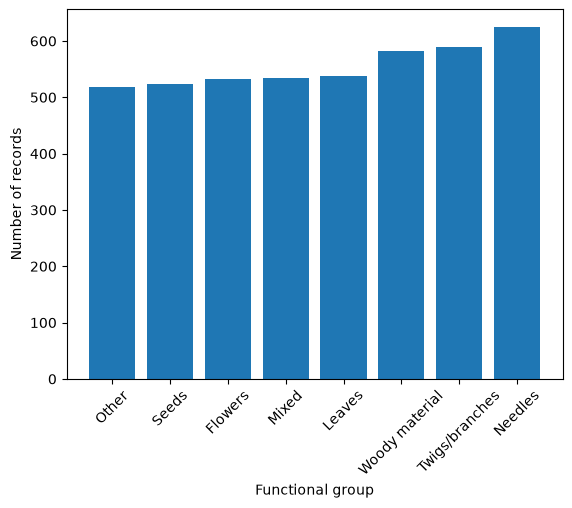

In [24]:
group_counts=Litter["functionalGroup"].value_counts()
group_counts=group_counts.sort_values()
plt.bar(group_counts.index,group_counts.values)

plt.xlabel("Functional group")
plt.ylabel("Number of records")
plt.xticks(rotation=45)

plt.show()

### ✅ 6.2 Examine the distribution of dry mass for each functional group
* Create a box plot of dry mass showing a separate box for each functional group. 
* TIP: 
    - Add the argument `vert=False` to rotate the plot 90 degrees for easier reading.
    - Also set the figure width x height to 14 x 5, also to make it more informative.

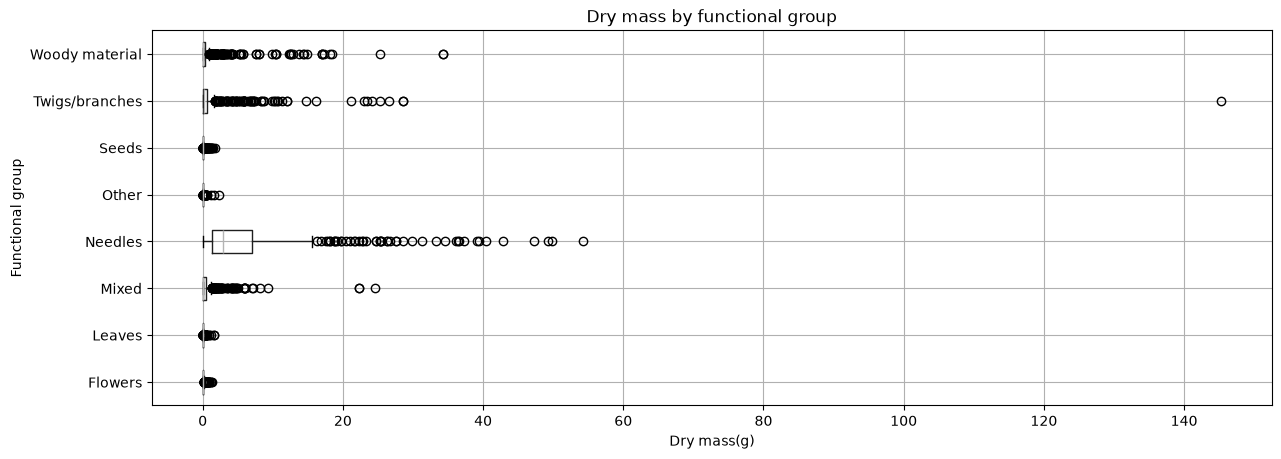

In [26]:
Litter.boxplot(
    column="dryMass",
    by="functionalGroup",
    vert=False,
    figsize=(14,5)
)

plt.xlabel("Dry mass(g)")
plt.ylabel("Functional group")
plt.title("Dry mass by functional group")
plt.suptitle("")

plt.show()

#### 🔸Interpretation
* Which functional group has the highest median dry mass? 

>Answer: Needles has the highest median dry mass, 2.86 g.

* Which functional group has the highest measured dry mass?

> Answer: Twigs/branches has the highest measured dry mass, 145.25 g.


### ✅ 6.3 Repeat the same plot but omitting the outliers 
* Include the argument `showfliers=False` to omit outliers.

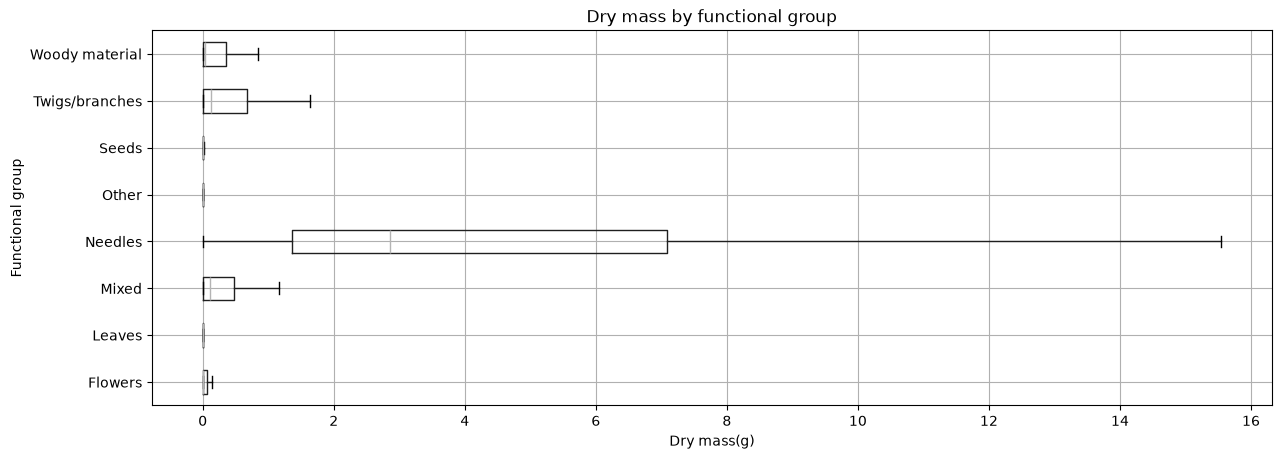

In [27]:
Litter.boxplot(
    column="dryMass",
    by="functionalGroup",
    vert=False,
    figsize=(14,5),
    showfliers=False
)

plt.xlabel("Dry mass(g)")
plt.ylabel("Functional group")
plt.title("Dry mass by functional group")
plt.suptitle("")

plt.show()

#### 🔸Interpretation
* Which functional group has the largest inter-quartile range?

> Answer: Needles has the largest interquartile range. Its Q1 is 1.36 g and Q3 is 7.09 g, so IQR = 5.73 g.


## ✳️ Submission
* Check that you have answered all the questions asked.
* Restart your notebook and then run all code cells. 
* Stage and commit the notebook to Git, push to GitHub
* Export your notebook to an HTML document
    - From the `...` item in the notebook menu, select Export, thn HTML
* Submit the PDF to Canvas.